In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROJECT_ROOT = os.path.dirname(os.getcwd())

DATA_PATH = os.path.join(PROJECT_ROOT, "data", "features", "penalties_features.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,match_id,period,minute,player_name,team_name,is_goal,outcome_name,start_x,start_y,end_x,end_y,end_z,gk_name,gk_position,shot_distance,shot_angle,placement_zone,is_shootout
0,3857264,1,38,Lionel Andrés Messi Cuccittini,Argentina,0,Saved,108.1,40.1,119.7,42.8,1.4,NaN,NaN,11.90042,37.156345,Low Center,0
1,3857265,2,57,Robert Lewandowski,Poland,0,Saved,108.1,40.0,118.7,42.9,0.4,NaN,NaN,11.90000,37.158541,Low Center,0
2,3857267,1,43,Ismaïla Sarr,Senegal,1,Goal,108.0,40.0,120.0,43.4,0.2,NaN,NaN,12.00000,36.869898,Low Center,0
3,3857268,1,10,Alphonso Davies,Canada,0,Saved,108.1,40.1,119.5,38.0,0.2,NaN,NaN,11.90042,37.156345,Low Center,0
4,3857270,2,92,Bruno Miguel Borges Fernandes,Portugal,1,Goal,108.0,40.0,120.0,38.2,0.6,NaN,NaN,12.00000,36.869898,Low Center,0


In [2]:
print(f"Total penalties: {len(df)}")
print(f"Overall Conversion Rate: {df['is_goal'].mean() * 100:.1f}%\n")

print("Conversion Rate: Regular Time vs Shootout")
print(df.groupby('is_shootout')['is_goal'].agg(['count', 'mean']))

Total penalties: 64
Overall Conversion Rate: 67.2%

Conversion Rate: Regular Time vs Shootout
             count      mean
is_shootout                 
0               23  0.739130
1               41  0.634146


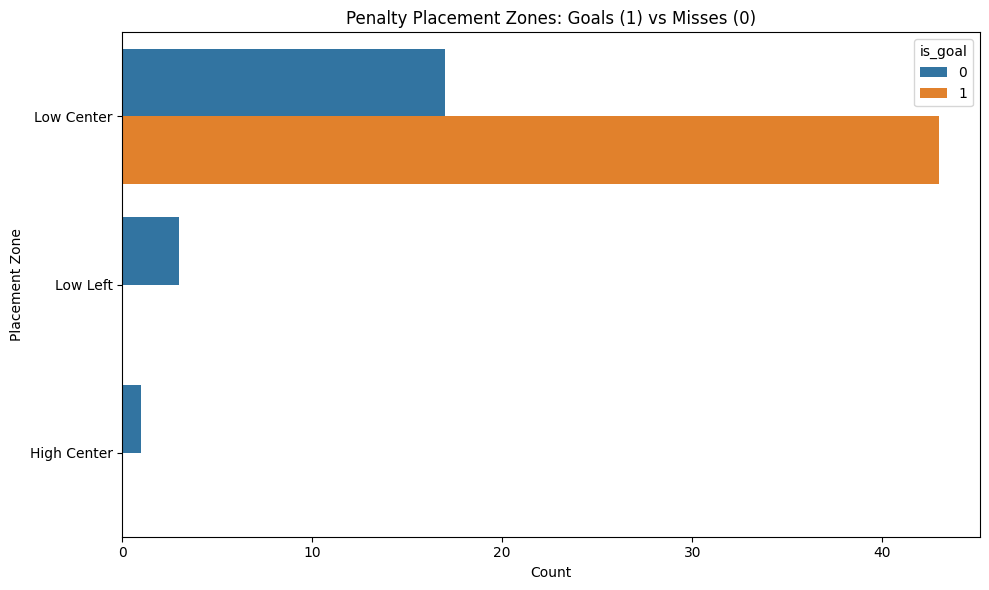

In [3]:
plt.figure(figsize=(10, 6))

# Create a countplot of where players place the ball
sns.countplot(data=df, y='placement_zone', hue='is_goal', order=df['placement_zone'].value_counts().index)
plt.title('Penalty Placement Zones: Goals (1) vs Misses (0)')
plt.xlabel('Count')
plt.ylabel('Placement Zone')
plt.tight_layout()
plt.show()

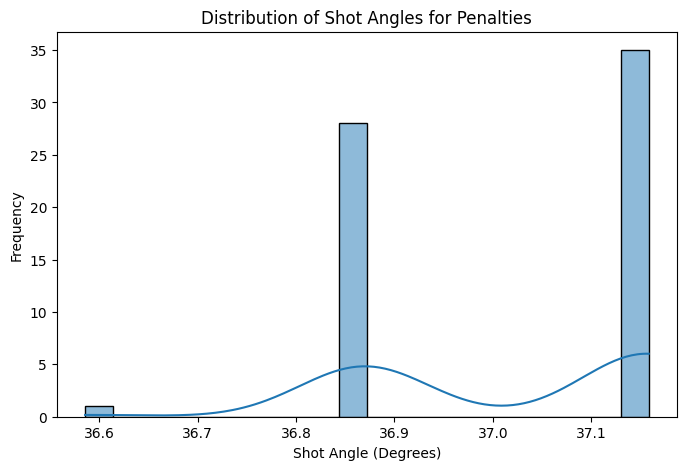

Average Shot Angle: 37.02 degrees


In [4]:
plt.figure(figsize=(8, 5))

# Plot the distribution of shot angles
sns.histplot(df['shot_angle'], bins=20, kde=True)
plt.title('Distribution of Shot Angles for Penalties')
plt.xlabel('Shot Angle (Degrees)')
plt.ylabel('Frequency')
plt.show()

print(f"Average Shot Angle: {df['shot_angle'].mean():.2f} degrees")